# Year Hired 


Overall, hiring increased from 1960-1980s then decreased after the 1980s. Hiring for females more commonly started after the 1970s and consistently stayed the same rate after the 1970s. However, historically, men have always been hired more than women. 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("salary.txt", sep=r"\s+")
df.head()

,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.0
1,2,2,M,Other,91,Other,94,94,Assist,0,4743.0
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.0
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.0
4,5,6,M,PhD,66,Other,91,91,Full,1,11182.0


In [9]:
df["year_hired"] = 1900 + df["startyr"]
df[["sex", "startyr", "year_hired"]].head()

,sex,startyr,year_hired
0,F,95,1995
1,M,94,1994
2,M,94,1994
3,M,95,1995
4,M,91,1991


Overall
count    19792.000000
mean      1976.072201
std          8.951341
min       1948.000000
25%       1969.000000
50%       1976.000000
75%       1983.000000
max       1995.000000
Name: year_hired, dtype: float64

By sex
       count         mean       std     min     25%     50%     75%     max
sex                                                                        
F     3926.0  1980.418492  8.093709  1957.0  1974.0  1980.0  1987.0  1995.0
M    15866.0  1974.996723  8.827049  1948.0  1968.0  1974.0  1982.0  1995.0


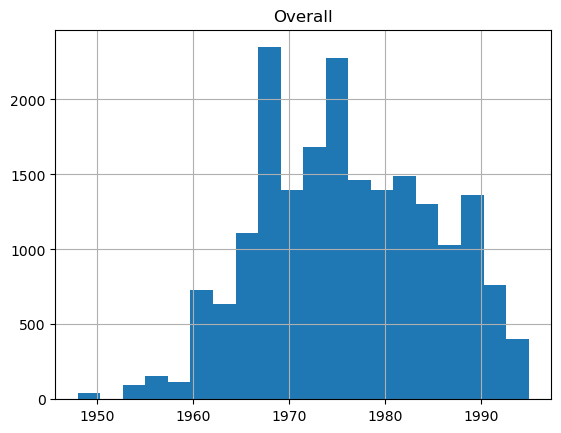

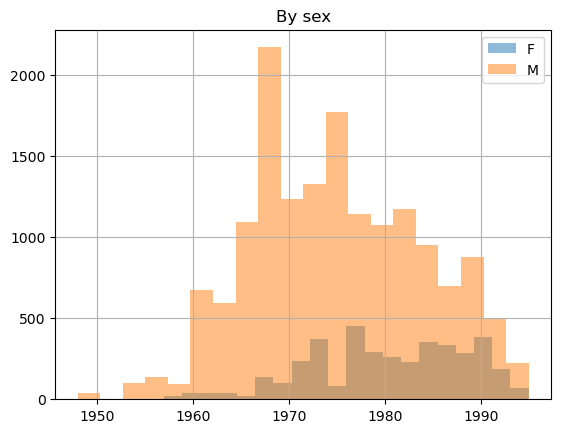

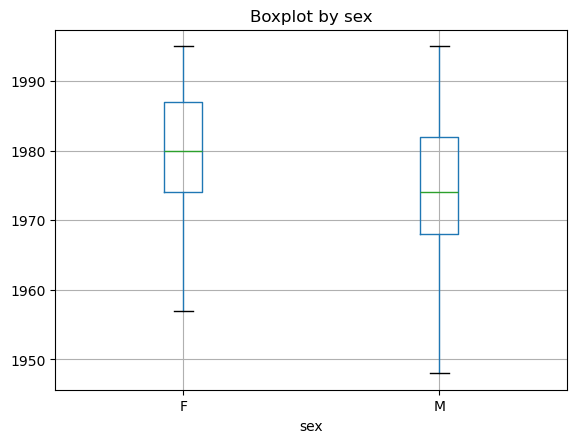

In [8]:
print("Overall")
print(df["year_hired"].describe())

print("\nBy sex")
print(df.groupby("sex")["year_hired"].describe())

df["year_hired"].hist(bins=20)
plt.title("Overall")
plt.show()

df[df["sex"] == "F"]["year_hired"].hist(bins=20, alpha=0.5, label="F")
df[df["sex"] == "M"]["year_hired"].hist(bins=20, alpha=0.5, label="M")
plt.title("By sex")
plt.legend()
plt.show()

df.boxplot(column="year_hired", by="sex")
plt.title("Boxplot by sex")
plt.suptitle("")
plt.show()

In [10]:
from scipy import stats

male = df[df["sex"] == "M"]["year_hired"]
female = df[df["sex"] == "F"]["year_hired"]

t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)

t-statistic: -36.893332813889316
p-value: 1.791966492170913e-270


Null hypothesis: mean year hired for female faculty is equal to mean year hired for male faculty. 

Alternative Hypothesis: mean year hired for female faculty is not equal to mean year hired for male faculty. 

Result: The p-value is very very small, so we reject the null hypothesis. There is strong statistical evidence that the mean hire year is influenced by sex. 